In [1]:
# Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('averaged_perceptron_tagger_eng')
print("✅ All dependencies installed and ready!")

✅ All dependencies installed and ready!


[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\jebarajj\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [2]:
# ── Core libraries ──────────────────────────────────────────────
import requests
import json
import re
import time
from datetime import datetime
# ── Data handling ────────────────────────────────────────────────
import pandas as pd
# ── NLP ──────────────────────────────────────────────────────────
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
# ── Web Scraping ─────────────────────────────────────────────────
from bs4 import BeautifulSoup
# ── Visualization ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')
print("✅ All imports successful!")

✅ All imports successful!


In [3]:
NEWS_API_KEY = "a75936f4a7374373a2cf3a8c67f46715"
CATEGORIES = ["technology", "business"]
SEARCH_QUERIES = ["economy", "artificial intelligence"]
PAGE_SIZE = 1
COUNTRY ="us"
BASE_URL = "https://newsapi.org/v2"

In [4]:
all_articles = []

In [5]:
def fetch_top_headlines(category:str, country:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/top-headlines"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "category": category,
       "country": country,
       "pageSize" : page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles
for cat in CATEGORIES:
   articles = fetch_top_headlines(category=cat, country=COUNTRY)
   for art in articles:
       art["query_category"] = cat
   all_articles.extend(articles)
print(all_articles)


https://newsapi.org/v2/top-headlines
{'apiKey': 'a75936f4a7374373a2cf3a8c67f46715', 'category': 'technology', 'country': 'us', 'pageSize': 1}
<Response [200]>
[{'source': {'id': None, 'name': 'Gematsu'}, 'author': 'Sal Romano', 'title': 'STRANGER THAN HEAVEN launches this winter - Gematsu', 'description': 'STRANGER THAN HEAVEN will launch for PlayStation 5, Xbox Series, and PC via Steam and Microsoft Store this winter, publisher SEGA and developer Ryu Ga Gotoku Studio announced. It will also be avail…', 'url': 'https://www.gematsu.com/2026/05/stranger-than-heaven-launches-this-winter', 'urlToImage': 'https://www.gematsu.com/wp-content/uploads/2026/05/STRANGER-THAN-HEAVEN-Ann_05-06-26.jpg', 'publishedAt': '2026-05-06T23:36:02Z', 'content': 'The theme song, “STRANGER THAN HEAVEN,” is performed by Snoop Dogg, Satoshi Fujihara, Ado, and Tori Kelly.About\r\nA fifty-year, actionadventure saga of men with nowhere to go and their desperate strug… [+4469 chars]'}]
https://newsapi.org/v2/top-hea

In [6]:
def fetch_by_keyword(query:str, page_size:int=PAGE_SIZE) -> list:
   url = f"{BASE_URL}/everything"
   print(url)
   request = {
       "apiKey" : NEWS_API_KEY,
       "q": query,
       "language": "en",
       "sortBy": "publishedAt",
       "pageSize": page_size
   }
   print(request)
   response = requests.get(url, params=request, timeout=10)
   print(response)
   if(response.status_code != 200):
       print(f" API error {response.status_code}")
   articles = response.json().get('articles', [])
   print(articles)
   return articles
for query in SEARCH_QUERIES:
   articles = fetch_by_keyword(query=query)
   for art in articles:
       art["query_category"] = f"kw:{query}"
   all_articles.extend(articles)

for art in all_articles:
   print(art)

https://newsapi.org/v2/everything
{'apiKey': 'a75936f4a7374373a2cf3a8c67f46715', 'q': 'economy', 'language': 'en', 'sortBy': 'publishedAt', 'pageSize': 1}
<Response [200]>
[{'source': {'id': 'abc-news-au', 'name': 'ABC News (AU)'}, 'author': 'Emma Wynne', 'title': 'Experts warn increasing self-reliance comes at a cost', 'description': "With the war in the Middle East focusing attention on fuel reserves and Australia's self-reliance, experts warn there is no quick, or cheap, fix to reducing dependence on global supply chains.", 'url': 'https://www.abc.net.au/news/2026-05-07/national-resilience-forum-warns-on-costs/106652030', 'urlToImage': 'https://live-production.wcms.abc-cdn.net.au/b51c433b64d771d969fa39e41fff24e4?impolicy=wcms_watermark_news&cropH=2916&cropW=5184&xPos=0&yPos=0&width=862&height=485&imformat=generic', 'publishedAt': '2026-05-07T02:37:24Z', 'content': 'There are calls for Australia to improve its self-reliance as war in the Middle East increases freight and fertiliser c

In [7]:
print(json.dumps(all_articles, indent=2))

[
  {
    "source": {
      "id": null,
      "name": "Gematsu"
    },
    "author": "Sal Romano",
    "title": "STRANGER THAN HEAVEN launches this winter - Gematsu",
    "description": "STRANGER THAN HEAVEN will launch for PlayStation 5, Xbox Series, and PC via Steam and Microsoft Store this winter, publisher SEGA and developer Ryu Ga Gotoku Studio announced. It will also be avail\u2026",
    "url": "https://www.gematsu.com/2026/05/stranger-than-heaven-launches-this-winter",
    "urlToImage": "https://www.gematsu.com/wp-content/uploads/2026/05/STRANGER-THAN-HEAVEN-Ann_05-06-26.jpg",
    "publishedAt": "2026-05-06T23:36:02Z",
    "content": "The theme song, \u201cSTRANGER THAN HEAVEN,\u201d is performed by Snoop Dogg, Satoshi Fujihara, Ado, and Tori Kelly.About\r\nA fifty-year, actionadventure saga of men with nowhere to go and their desperate strug\u2026 [+4469 chars]",
    "query_category": "technology"
  },
  {
    "source": {
      "id": "the-verge",
      "name": "The Verge"
    }

In [8]:
def articles_to_dataframe(articles:list) -> pd.DataFrame:
   rows = []
   for art in articles:
       rows.append({
           "title": art.get("title") or "",
           "description" : art.get("description") or "",
           "source" : art.get("source", {}).get("name") or "Unknown",
           "url": art.get("url") or "",
           "published_at" : art.get("publishedAt") or "",
           "category" : art.get("query_category"),
           "full_text" : " ".join(filter(None, [
               art.get("title") or "",
               art.get("description") or "",
               art.get("content") or ""
           ]))
       })
   df = pd.DataFrame(rows)
   return df

In [9]:
df = articles_to_dataframe(all_articles)
df.head()

,title,description,source,url,published_at,category,full_text
0,STRANGER THAN HEAVEN launches this winter - Ge...,STRANGER THAN HEAVEN will launch for PlayStati...,Gematsu,https://www.gematsu.com/2026/05/stranger-than-...,2026-05-06T23:36:02Z,technology,STRANGER THAN HEAVEN launches this winter - Ge...
1,Musk’s biggest loyalist became his biggest lia...,Shivon Zillis is a former OpenAI board member ...,The Verge,https://www.theverge.com/ai-artificial-intelli...,2026-05-06T23:37:02Z,business,Musk’s biggest loyalist became his biggest lia...
2,Experts warn increasing self-reliance comes at...,With the war in the Middle East focusing atten...,ABC News (AU),https://www.abc.net.au/news/2026-05-07/nationa...,2026-05-07T02:37:24Z,kw:economy,Experts warn increasing self-reliance comes at...
3,"India, Japan sign quantum technology and healt...",India and Japan signed agreements on quantum t...,BusinessLine,https://www.thehindubusinessline.com/news/scie...,2026-05-07T02:33:37Z,kw:artificial intelligence,"India, Japan sign quantum technology and healt..."


In [10]:
# ── Regex patterns used in this project ─────────────────────────
PATTERNS = {
   "url":         re.compile(r'https?://\S+'),
   #before → "Read more at https://bbc.com/news/article-123 today"
   #after  → "Read more at   today"
   "html_tag":    re.compile(r'<[^>]+>'),
   #before → "<b>BREAKING:</b> Markets <em>fall</em> sharply"
   #after  → " BREAKING:  Markets  fall  sharply"
   "punctuation": re.compile(r'[^a-zA-Z\s]'),
   #before → "Apple stock up 3.4% — best day since 2021!"
   #after  → "Apple stock up      best day since      "
   "extra_space": re.compile(r'\s+'),
   #before → "Apple   stock    up      best   day"
   #after  → "Apple stock up best day"
   "ticker":      re.compile(r'\b[A-Z]{2,5}\b'),          # stock tickers / abbreviations
   #input   → "AAPL and TSLA both rose as NASA announced funding"
   #extracts → ["AAPL", "TSLA", "NASA"]
   "proper_noun": re.compile(r'\b[A-Z][a-z]+(?:\s[A-Z][a-z]+)+'),  # naive NER
   #input    → "Elon Musk met Tim Cook in New York yesterday"
   #extracts → ["Elon Musk", "Tim Cook", "New York"]
   "year":        re.compile(r'\b(19|20)\d{2}\b'),
   #input    → "The 2024 budget follows the 2023 deficit report"
   #extracts → ["2024", "2023"]
   "number":      re.compile(r'\b\d+\.?\d*\b'),
   #input    → "Stocks fell 4.2 points and GDP grew by 1 percent"
   #extracts → ["4.2", "1"]
   "chars_bracket": re.compile(r'\[\+?\d+\s*chars?\]'),   # NewsAPI truncation marker
   #before → "The economy shrank [+247 chars]"
   #after  → "The economy shrank  "
}

In [11]:
def clean_text(text: str) -> str:
   """Full regex cleaning pipeline for NLP."""
   text = PATTERNS["html_tag"].sub(' ', text)        # remove HTML tags
   text = PATTERNS["url"].sub(' ', text)             # remove URLs
   text = PATTERNS["chars_bracket"].sub(' ', text)   # remove [+N chars] artifacts
   text = PATTERNS["punctuation"].sub(' ', text)     # remove punctuation/numbers
   text = PATTERNS["extra_space"].sub(' ', text)     # normalize whitespace
   return text.strip().lower()

 

In [12]:
print(clean_text('Stocks fell 4.2 points and GDP grew by 1 percent'))

 

stocks fell points and gdp grew by percent


In [13]:
def extract_proper_nouns(text: str) -> list:
   """Extract likely named entities using a regex heuristic."""
   return PATTERNS["proper_noun"].findall(text)

print(extract_proper_nouns('Elon Musk met Tim Cook in New York yesterday'))

['Elon Musk', 'Tim Cook', 'New York']


In [14]:
def extract_tickers(text: str) -> list:
   """Extract stock ticker / acronym candidates."""
   return PATTERNS["ticker"].findall(text)

In [15]:
df["clean_text"]    = df["full_text"].apply(clean_text)

In [16]:
df["proper_nouns"]  = df["full_text"].apply(extract_proper_nouns)

In [17]:
df["tickers"]       = df["title"].apply(extract_tickers)

In [18]:
STOP_WORDS = set(stopwords.words('english'))
print(STOP_WORDS)


{'he', 'a', 'is', 's', 'll', 'on', 'same', 'theirs', 'these', "we've", 'your', 'other', 'am', 'will', "should've", 've', 'be', 'o', 'themselves', "she'd", 'wasn', 'about', 'my', 'just', 'having', "didn't", 'himself', 'than', 'were', 'shan', 'an', 'can', 'had', 'during', "it's", 'are', "i've", "hasn't", 'only', 'here', 'own', "she's", 'hers', "doesn't", 'through', "mightn't", 'then', 'who', 'we', 'hadn', 'her', "it'll", 'has', "wasn't", 'them', 'both', 'herself', "that'll", 'for', 'to', 'our', 'what', 'isn', 'by', "she'll", 'above', 'now', 'm', "won't", 'yours', 'under', 'because', 'if', "mustn't", 'did', 'you', "we'd", 'too', "don't", 'which', "you've", "wouldn't", 'most', 'hasn', 'against', 'where', 'they', 'any', 'after', "shouldn't", "we'll", 'don', "weren't", 'and', 'weren', 'out', 'each', 'up', 'mustn', 'she', 'been', 'do', "i'm", 'or', 'me', 'won', 'yourselves', "you'll", "he'd", 'him', 'didn', 'y', 'doesn', 'few', 'it', 'that', 'before', 'mightn', 'myself', 'his', 'from', 'betwe

In [19]:
# Add domain-specific stopwords
STOP_WORDS.update(['said', 'say', 'says', 'new', 'us', 'also', 'one', 'two',
                  'would', 'could', 'may', 'will', 'get', 'got', 'year',
                  'first', 'last', 'week', 'day', 'time', 'report'])

In [20]:
def tokenize_and_filter(text: str) -> list:
   """Tokenize text and remove stopwords & short tokens."""
   tokens = word_tokenize(text)
   print('split into words', tokens)                            # split into words
   tokens = [t for t in tokens if t.isalpha()]    
   print(' keep only alphabetic', tokens)        # keep only alphabetic
   tokens = [t for t in tokens if t not in STOP_WORDS]    # remove stopwords
   print('remove stopwords', tokens)
   tokens = [t for t in tokens if len(t) > 2]             # remove very short words
   print('remove very short words', tokens)
   return tokens

In [21]:
print(tokenize_and_filter('The 2024 budget by follows the 2023 deficit report'))

split into words ['The', '2024', 'budget', 'by', 'follows', 'the', '2023', 'deficit', 'report']
 keep only alphabetic ['The', 'budget', 'by', 'follows', 'the', 'deficit', 'report']
remove stopwords ['The', 'budget', 'follows', 'deficit']
remove very short words ['The', 'budget', 'follows', 'deficit']
['The', 'budget', 'follows', 'deficit']


In [22]:
 df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers
0,STRANGER THAN HEAVEN launches this winter - Ge...,STRANGER THAN HEAVEN will launch for PlayStati...,Gematsu,https://www.gematsu.com/2026/05/stranger-than-...,2026-05-06T23:36:02Z,technology,STRANGER THAN HEAVEN launches this winter - Ge...,stranger than heaven launches this winter gema...,"[Xbox Series, Microsoft Store, Ryu Ga Gotoku S...",[THAN]
1,Musk’s biggest loyalist became his biggest lia...,Shivon Zillis is a former OpenAI board member ...,The Verge,https://www.theverge.com/ai-artificial-intelli...,2026-05-06T23:37:02Z,business,Musk’s biggest loyalist became his biggest lia...,musk s biggest loyalist became his biggest lia...,"[The Verge Shivon Zillis, Shivon Zilis, Shivon...",[]
2,Experts warn increasing self-reliance comes at...,With the war in the Middle East focusing atten...,ABC News (AU),https://www.abc.net.au/news/2026-05-07/nationa...,2026-05-07T02:37:24Z,kw:economy,Experts warn increasing self-reliance comes at...,experts warn increasing self reliance comes at...,"[Middle East, Middle East, For Andrew Hastie]",[]
3,"India, Japan sign quantum technology and healt...",India and Japan signed agreements on quantum t...,BusinessLine,https://www.thehindubusinessline.com/news/scie...,2026-05-07T02:33:37Z,kw:artificial intelligence,"India, Japan sign quantum technology and healt...",india japan sign quantum technology and health...,[],[]


In [23]:
 # Apply to all articles
df["tokens"] = df["clean_text"].apply(tokenize_and_filter)
df["token_count"] = df["tokens"].apply(len)

split into words ['stranger', 'than', 'heaven', 'launches', 'this', 'winter', 'gematsu', 'stranger', 'than', 'heaven', 'will', 'launch', 'for', 'playstation', 'xbox', 'series', 'and', 'pc', 'via', 'steam', 'and', 'microsoft', 'store', 'this', 'winter', 'publisher', 'sega', 'and', 'developer', 'ryu', 'ga', 'gotoku', 'studio', 'announced', 'it', 'will', 'also', 'be', 'avail', 'the', 'theme', 'song', 'stranger', 'than', 'heaven', 'is', 'performed', 'by', 'snoop', 'dogg', 'satoshi', 'fujihara', 'ado', 'and', 'tori', 'kelly', 'about', 'a', 'fifty', 'year', 'actionadventure', 'saga', 'of', 'men', 'with', 'nowhere', 'to', 'go', 'and', 'their', 'desperate', 'strug']
 keep only alphabetic ['stranger', 'than', 'heaven', 'launches', 'this', 'winter', 'gematsu', 'stranger', 'than', 'heaven', 'will', 'launch', 'for', 'playstation', 'xbox', 'series', 'and', 'pc', 'via', 'steam', 'and', 'microsoft', 'store', 'this', 'winter', 'publisher', 'sega', 'and', 'developer', 'ryu', 'ga', 'gotoku', 'studio', '

In [24]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
freq_dist  = FreqDist(all_tokens)

In [25]:
print(f"Total tokens (after cleaning): {len(all_tokens):,}")
print(f"Unique tokens: {len(freq_dist):,}")
print("\nTop 20 most frequent words:")
for word, count in freq_dist.most_common(20):
   print(f"  {word:20s} {count:4d}")

Total tokens (after cleaning): 170
Unique tokens: 119

Top 20 most frequent words:
  stranger                3
  heaven                  3
  shivon                  3
  notes                   3
  might                   3
  important               3
  evidence                3
  seen                    3
  far                     3
  self                    3
  reliance                3
  india                   3
  japan                   3
  technology              3
  healthcare              3
  agreements              3
  winter                  2
  musk                    2
  biggest                 2
  zilis                   2


In [26]:
# ── Visualize: Top 25 words bar chart ───────────────────────────
top_words = freq_dist.most_common(25)
words, counts = zip(*top_words)

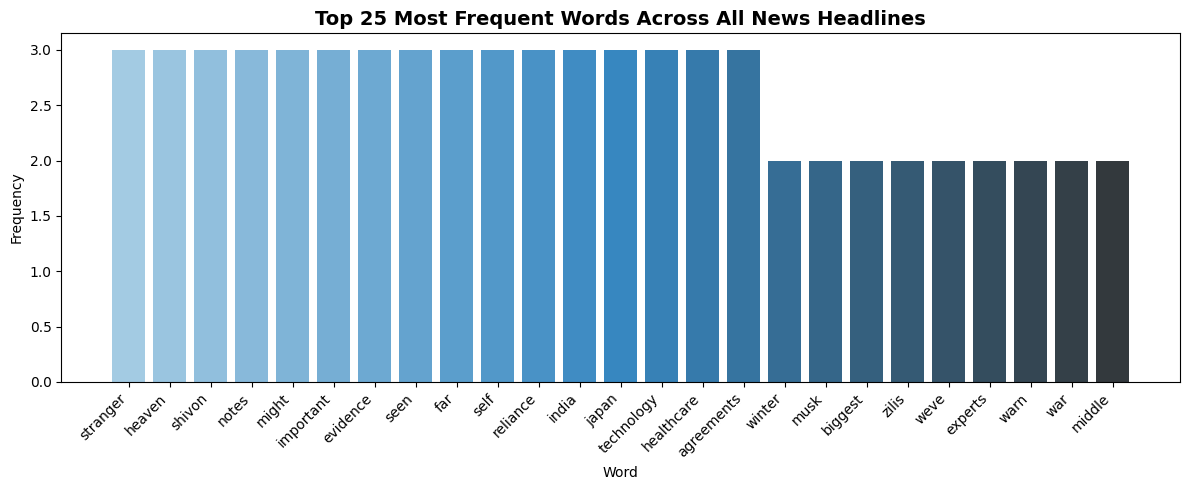

✅ Frequency chart displayed


In [27]:
plt.figure(figsize=(12, 5))
bars = plt.bar(words, counts, color=sns.color_palette("Blues_d", 25))
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title("Top 25 Most Frequent Words Across All News Headlines", fontsize=14, fontweight='bold')
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()
print("✅ Frequency chart displayed")

In [28]:
text_for_cloud = " ".join(all_tokens)

In [29]:
print(all_tokens)

['stranger', 'heaven', 'launches', 'winter', 'gematsu', 'stranger', 'heaven', 'launch', 'playstation', 'xbox', 'series', 'via', 'steam', 'microsoft', 'store', 'winter', 'publisher', 'sega', 'developer', 'ryu', 'gotoku', 'studio', 'announced', 'avail', 'theme', 'song', 'stranger', 'heaven', 'performed', 'snoop', 'dogg', 'satoshi', 'fujihara', 'ado', 'tori', 'kelly', 'fifty', 'actionadventure', 'saga', 'men', 'nowhere', 'desperate', 'strug', 'musk', 'biggest', 'loyalist', 'became', 'biggest', 'liability', 'verge', 'shivon', 'zillis', 'former', 'openai', 'board', 'member', 'mother', 'several', 'musk', 'children', 'notes', 'might', 'important', 'evidence', 'seen', 'far', 'shivon', 'zilis', 'notes', 'might', 'important', 'evidence', 'weve', 'seen', 'far', 'shivon', 'zilis', 'notes', 'might', 'important', 'evidence', 'weve', 'seen', 'far', 'elizabe', 'experts', 'warn', 'increasing', 'self', 'reliance', 'comes', 'cost', 'war', 'middle', 'east', 'focusing', 'attention', 'fuel', 'reserves', 'au

In [30]:
print(text_for_cloud)

stranger heaven launches winter gematsu stranger heaven launch playstation xbox series via steam microsoft store winter publisher sega developer ryu gotoku studio announced avail theme song stranger heaven performed snoop dogg satoshi fujihara ado tori kelly fifty actionadventure saga men nowhere desperate strug musk biggest loyalist became biggest liability verge shivon zillis former openai board member mother several musk children notes might important evidence seen far shivon zilis notes might important evidence weve seen far shivon zilis notes might important evidence weve seen far elizabe experts warn increasing self reliance comes cost war middle east focusing attention fuel reserves australia self reliance experts warn quick cheap fix reducing dependence global supply chains calls australia improve self reliance war middle east increases freight fertiliser costs putting strain supply chains andrew hastie federal opposition india japan sign quantum technology healthcare cooperati

In [31]:
wc = WordCloud(
   width=900, height=400,
   background_color='white',
   colormap='RdYlGn',
   max_words=150,
   collocations=False
).generate(text_for_cloud)

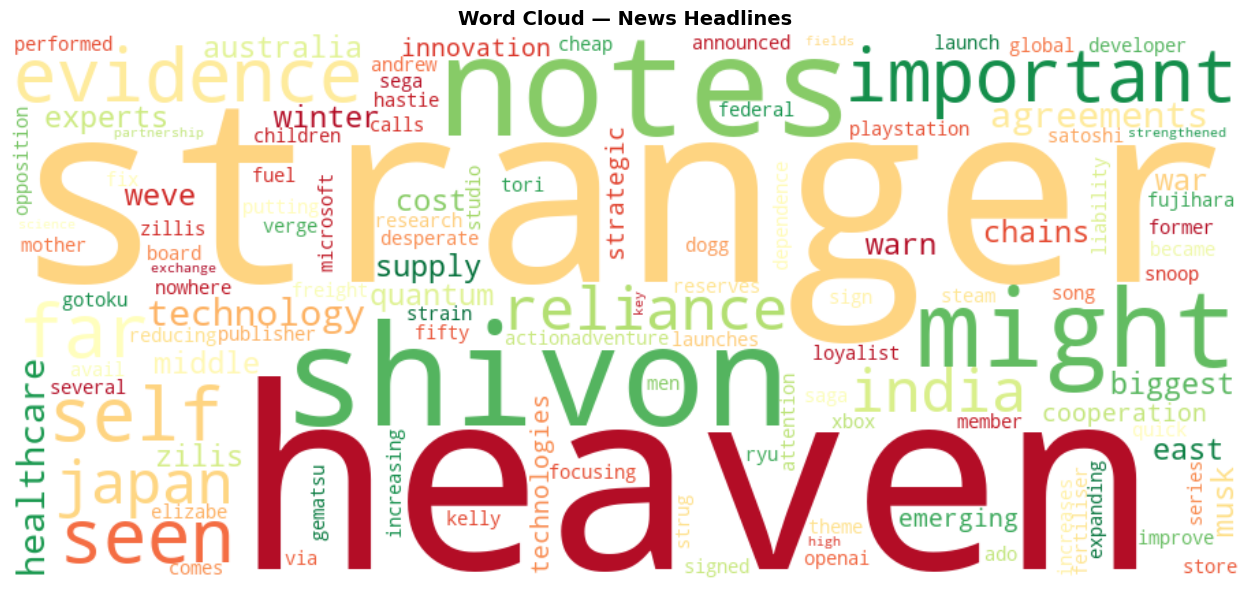

✅ Word cloud displayed


In [32]:
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud — News Headlines", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("✅ Word cloud displayed")

In [33]:
tagged = nltk.pos_tag(df["tokens"][0])
print(tagged)

[('stranger', 'NN'), ('heaven', 'NN'), ('launches', 'NNS'), ('winter', 'VBP'), ('gematsu', 'JJ'), ('stranger', 'NN'), ('heaven', 'VBN'), ('launch', 'JJ'), ('playstation', 'NN'), ('xbox', 'NNP'), ('series', 'NN'), ('via', 'IN'), ('steam', 'NN'), ('microsoft', 'NN'), ('store', 'NN'), ('winter', 'NN'), ('publisher', 'NN'), ('sega', 'JJ'), ('developer', 'NN'), ('ryu', 'NN'), ('gotoku', 'NN'), ('studio', 'NN'), ('announced', 'VBD'), ('avail', 'JJ'), ('theme', 'NN'), ('song', 'NN'), ('stranger', 'NN'), ('heaven', 'NN'), ('performed', 'VBD'), ('snoop', 'JJ'), ('dogg', 'NN'), ('satoshi', 'NN'), ('fujihara', 'NN'), ('ado', 'NN'), ('tori', 'NN'), ('kelly', 'RB'), ('fifty', 'JJ'), ('actionadventure', 'NN'), ('saga', 'VBN'), ('men', 'NNS'), ('nowhere', 'RB'), ('desperate', 'JJ'), ('strug', 'NN')]


In [34]:
# ──Part-of-Speech (POS) tagging  — identify noun-heavy vs action-heavy headlines ──
def pos_tag_summary(tokens: list) -> dict:
   """Return counts of nouns, verbs, adjectives in a token list."""
   tagged = nltk.pos_tag(tokens)
   pos_counts = {"NN": 0, "VB": 0, "JJ": 0}  # nouns, verbs, adjectives
   for _, tag in tagged:
       if tag.startswith("NN"): pos_counts["NN"] += 1
       elif tag.startswith("VB"): pos_counts["VB"] += 1
       elif tag.startswith("JJ"): pos_counts["JJ"] += 1
   return pos_counts

In [35]:
sample_df = df.head(50).copy()

In [36]:
sample_df["pos_tags"] = sample_df["tokens"].apply(pos_tag_summary)
sample_df["noun_count"] = sample_df["pos_tags"].apply(lambda x: x["NN"])
sample_df["verb_count"] = sample_df["pos_tags"].apply(lambda x: x["VB"])
sample_df["adj_count"]  = sample_df["pos_tags"].apply(lambda x: x["JJ"])
sample_df.head()

,title,description,source,url,published_at,category,full_text,clean_text,proper_nouns,tickers,tokens,token_count,pos_tags,noun_count,verb_count,adj_count
0,STRANGER THAN HEAVEN launches this winter - Ge...,STRANGER THAN HEAVEN will launch for PlayStati...,Gematsu,https://www.gematsu.com/2026/05/stranger-than-...,2026-05-06T23:36:02Z,technology,STRANGER THAN HEAVEN launches this winter - Ge...,stranger than heaven launches this winter gema...,"[Xbox Series, Microsoft Store, Ryu Ga Gotoku S...",[THAN],"[stranger, heaven, launches, winter, gematsu, ...",43,"{'NN': 28, 'VB': 5, 'JJ': 7}",28,5,7
1,Musk’s biggest loyalist became his biggest lia...,Shivon Zillis is a former OpenAI board member ...,The Verge,https://www.theverge.com/ai-artificial-intelli...,2026-05-06T23:37:02Z,business,Musk’s biggest loyalist became his biggest lia...,musk s biggest loyalist became his biggest lia...,"[The Verge Shivon Zillis, Shivon Zilis, Shivon...",[],"[musk, biggest, loyalist, became, biggest, lia...",42,"{'NN': 17, 'VB': 6, 'JJ': 11}",17,6,11
2,Experts warn increasing self-reliance comes at...,With the war in the Middle East focusing atten...,ABC News (AU),https://www.abc.net.au/news/2026-05-07/nationa...,2026-05-07T02:37:24Z,kw:economy,Experts warn increasing self-reliance comes at...,experts warn increasing self reliance comes at...,"[Middle East, Middle East, For Andrew Hastie]",[],"[experts, warn, increasing, self, reliance, co...",47,"{'NN': 22, 'VB': 13, 'JJ': 11}",22,13,11
3,"India, Japan sign quantum technology and healt...",India and Japan signed agreements on quantum t...,BusinessLine,https://www.thehindubusinessline.com/news/scie...,2026-05-07T02:33:37Z,kw:artificial intelligence,"India, Japan sign quantum technology and healt...",india japan sign quantum technology and health...,[],[],"[india, japan, sign, quantum, technology, heal...",38,"{'NN': 25, 'VB': 6, 'JJ': 6}",25,6,6


In [38]:
print("POS distribution (sample of 50 headlines):")
print(f"  Avg nouns per headline:      {sample_df['noun_count'].mean():.1f}")
print(f"  Avg verbs per headline:      {sample_df['verb_count'].mean():.1f}")
print(f"  Avg adjectives per headline: {sample_df['adj_count'].mean():.1f}")

POS distribution (sample of 50 headlines):
  Avg nouns per headline:      23.0
  Avg verbs per headline:      10.3
  Avg adjectives per headline: 7.7


In [37]:
# ── Initialise VADER ─────────────────────────────────────────────
vader = SentimentIntensityAnalyzer()

def vader_sentiment(text: str) -> dict:
   """Run VADER on raw (uncleaned) text — VADER works best on original text."""
   scores = vader.polarity_scores(text)
   compound = scores['compound']
   if compound >= 0.05:
       label = "Positive"
   elif compound <= -0.05:
       label = "Negative"
   else:
       label = "Neutral"
   return {"vader_compound": compound,
           "vader_pos": scores['pos'],
           "vader_neu": scores['neu'],
           "vader_neg": scores['neg'],
           "vader_label": label}

In [38]:
def textblob_sentiment(text: str) -> dict:
   """Run TextBlob on text."""
   blob = TextBlob(text)
   pol  = blob.sentiment.polarity
   subj = blob.sentiment.subjectivity
   if pol > 0.05:     label = "Positive"
   elif pol < -0.05:  label = "Negative"
   else:              label = "Neutral"
   return {"tb_polarity": pol, "tb_subjectivity": subj, "tb_label": label}

In [39]:
# ── Apply to every headline (use title + description for best results) ─
print("Running sentiment analysis...")
vader_results  = df["full_text"].apply(vader_sentiment).apply(pd.Series)
textblob_results = df["full_text"].apply(textblob_sentiment).apply(pd.Series)
df = pd.concat([df, vader_results, textblob_results], axis=1)

Running sentiment analysis...


In [40]:
# Consensus label (agree → use it, disagree → call it Neutral)
def consensus_label(row):
   if row["vader_label"] == row["tb_label"]:
       return row["vader_label"]
   # If one says Neutral and other says Positive/Negative, trust the non-neutral one
   if row["vader_label"] == "Neutral": return row["tb_label"]
   if row["tb_label"]    == "Neutral": return row["vader_label"]
   return "Neutral"  # conflicting non-neutral → call it Neutral

In [41]:
df["consensus_label"] = df.apply(consensus_label, axis=1)
print(f"\n✅ Sentiment analysis complete on {len(df)} articles")
print("\nConsensus label distribution:")
print(df["consensus_label"].value_counts())


✅ Sentiment analysis complete on 4 articles

Consensus label distribution:
consensus_label
Positive    2
Neutral     1
Negative    1
Name: count, dtype: int64


In [42]:
print(df[["title", "vader_label", "tb_label", "consensus_label"]].head(10))

                                               title vader_label  tb_label  \
0  STRANGER THAN HEAVEN launches this winter - Ge...    Positive  Negative   
1  Musk’s biggest loyalist became his biggest lia...    Positive  Positive   
2  Experts warn increasing self-reliance comes at...    Negative   Neutral   
3  India, Japan sign quantum technology and healt...    Positive   Neutral   

  consensus_label  
0         Neutral  
1        Positive  
2        Negative  
3        Positive  


In [43]:
# ── Show example headlines with their sentiment scores ───────────
cols = ["title", "category", "vader_compound", "tb_polarity", "tb_subjectivity", "consensus_label"]
display_df = df[cols].sort_values("vader_compound", ascending=False)

In [44]:
print("🟢 Top 5 Most POSITIVE headlines:")
for _, row in display_df.head(5).iterrows():
   print(f"  [{row['consensus_label']:8s} | score: {row['vader_compound']:+.2f}] {row['title'][:80]}")

🟢 Top 5 Most POSITIVE headlines:
  [Positive | score: +0.91] India, Japan sign quantum technology and healthcare cooperation agreements
  [Neutral  | score: +0.78] STRANGER THAN HEAVEN launches this winter - Gematsu
  [Positive | score: +0.72] Musk’s biggest loyalist became his biggest liability - The Verge
  [Negative | score: -0.84] Experts warn increasing self-reliance comes at a cost


In [45]:
# ── Visualize 1: Sentiment distribution by category ──────────────
COLOR_MAP = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}
cat_sentiment = df.groupby(["category", "consensus_label"]).size().unstack(fill_value=0)
cat_sentiment_pct = cat_sentiment.div(cat_sentiment.sum(axis=1), axis=0) * 100


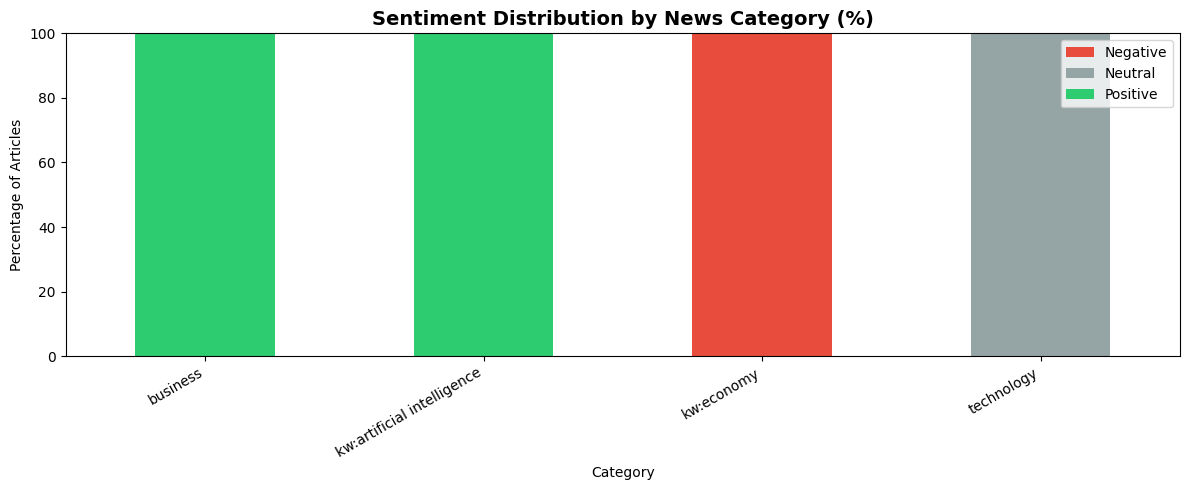

✅ Stacked bar chart displayed


In [46]:
ax = cat_sentiment_pct.plot(
   kind='bar', stacked=True, figsize=(12, 5),
   color=[COLOR_MAP.get(c, '#cccccc') for c in cat_sentiment_pct.columns]
)
plt.title("Sentiment Distribution by News Category (%)", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Percentage of Articles")
plt.xticks(rotation=30, ha='right')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()
print("✅ Stacked bar chart displayed")

In [47]:
HEADERS = {
   "User-Agent": (
       "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
       "AppleWebKit/537.36 (KHTML, like Gecko) "
       "Chrome/120.0.0.0 Safari/537.36"
   )
}

In [48]:
def scrape_article_text(url: str, timeout: int = 8) -> str:
   """
   Scrape full article text from a given URL.
   Returns cleaned paragraph text or empty string on failure.
   """
   try:
       response = requests.get(url, headers=HEADERS, timeout=timeout)
       response.raise_for_status()                        # raise on 4xx/5xx
       soup = BeautifulSoup(response.text, 'html.parser')
       # ── Strategy 1: look for <article> tag (modern sites) ────
       article_tag = soup.find('article')
       if article_tag:
           paragraphs = article_tag.find_all('p')
       else:
           # ── Strategy 2: fall back to all <p> tags ────────────
           paragraphs = soup.find_all('p')
       # Extract and join non-empty paragraph text
       text = ' '.join(
           p.get_text(strip=True)
           for p in paragraphs
           if len(p.get_text(strip=True)) > 40   # skip tiny/nav paragraphs
       )
       return text[:3000]   # cap at 3000 chars to keep things fast
   except Exception as e:
       return ""   # silently skip failed URLs

In [49]:
# ── Scrape a small sample (5 articles) to demonstrate ────────────
# (Scraping all 100+ would be slow — use a subset for the lab)
SCRAPE_SAMPLE = 5
scrape_sample = df[df["url"].str.startswith("http")].head(SCRAPE_SAMPLE).copy()
print(f"Scraping {SCRAPE_SAMPLE} full articles...")
scraped_texts = []
for i, (idx, row) in enumerate(scrape_sample.iterrows()):
   text = scrape_article_text(row["url"])
   word_count = len(text.split()) if text else 0
   scraped_texts.append(text)
   status = "✅" if text else "⚠️ "
   print(f"  {status} [{i+1}/{SCRAPE_SAMPLE}] {row['source']:20s} → {word_count:4d} words")
   time.sleep(1)   # be polite — 1 second between requests
scrape_sample["scraped_text"] = scraped_texts
print("\nDone!")

Scraping 5 full articles...
  ✅ [1/5] Gematsu              →  499 words
  ✅ [2/5] The Verge            →  523 words
  ✅ [3/5] ABC News (AU)        →  474 words
  ✅ [4/5] BusinessLine         →  419 words

Done!


In [50]:
# ── Inspect what was scraped ─────────────────────────────────────
for _, row in scrape_sample.iterrows():
   if row["scraped_text"]:
       print(f"\n{'='*60}")
       print(f"SOURCE  : {row['source']}")
       print(f"HEADLINE: {row['title'][:80]}")
       print(f"SCRAPED TEXT PREVIEW (first 300 chars):")
       print(f"  {row['scraped_text'][:300]}...")
       break   # show just one example
# ── Analyse scraped text with BeautifulSoup metadata extraction ──
def extract_page_metadata(url: str) -> dict:
   """
   Extract metadata (og:title, og:description, keywords) from a page.
   Demonstrates BeautifulSoup meta tag parsing.
   """
   try:
       response = requests.get(url, headers=HEADERS, timeout=8)
       soup = BeautifulSoup(response.text, 'html.parser')
       def get_meta(prop):
           tag = soup.find('meta', property=prop) or soup.find('meta', attrs={'name': prop})
           return tag['content'] if tag and tag.get('content') else None
       return {
           "og_title":       get_meta('og:title'),
           "og_description": get_meta('og:description'),
           "meta_keywords":  get_meta('keywords'),
           "h1_tags":        [h.get_text(strip=True) for h in soup.find_all('h1')][:3]
       }
   except Exception:
       return {}


SOURCE  : Gematsu
HEADLINE: STRANGER THAN HEAVEN launches this winter - Gematsu
SCRAPED TEXT PREVIEW (first 300 chars):
  STRANGER THAN HEAVENwill launch forPlayStation 5,Xbox Series, andPCviaSteamandMicrosoft Storethis winter, publisherSEGAand developerRyu Ga Gotoku Studioannounced. It will also be available via Game Pass. The theme song, “STRANGER THAN HEAVEN,” is performed by Snoop Dogg, Satoshi Fujihara, Ado, and T...


In [51]:
# Demo on first article
sample_url = df[df["url"].str.startswith("http")]["url"].iloc[0]
meta = extract_page_metadata(sample_url)
print("Page metadata extracted via BeautifulSoup:")
for key, val in meta.items():
   print(f"  {key:20s}: {str(val)[:80]}")

Page metadata extracted via BeautifulSoup:
  og_title            : STRANGER THAN HEAVEN launches this winter
  og_description      : STRANGER THAN HEAVEN will launch for PlayStation 5, Xbox Series, and PC via Stea
  meta_keywords       : None
  h1_tags             : ['STRANGER THAN HEAVEN launches this winter']


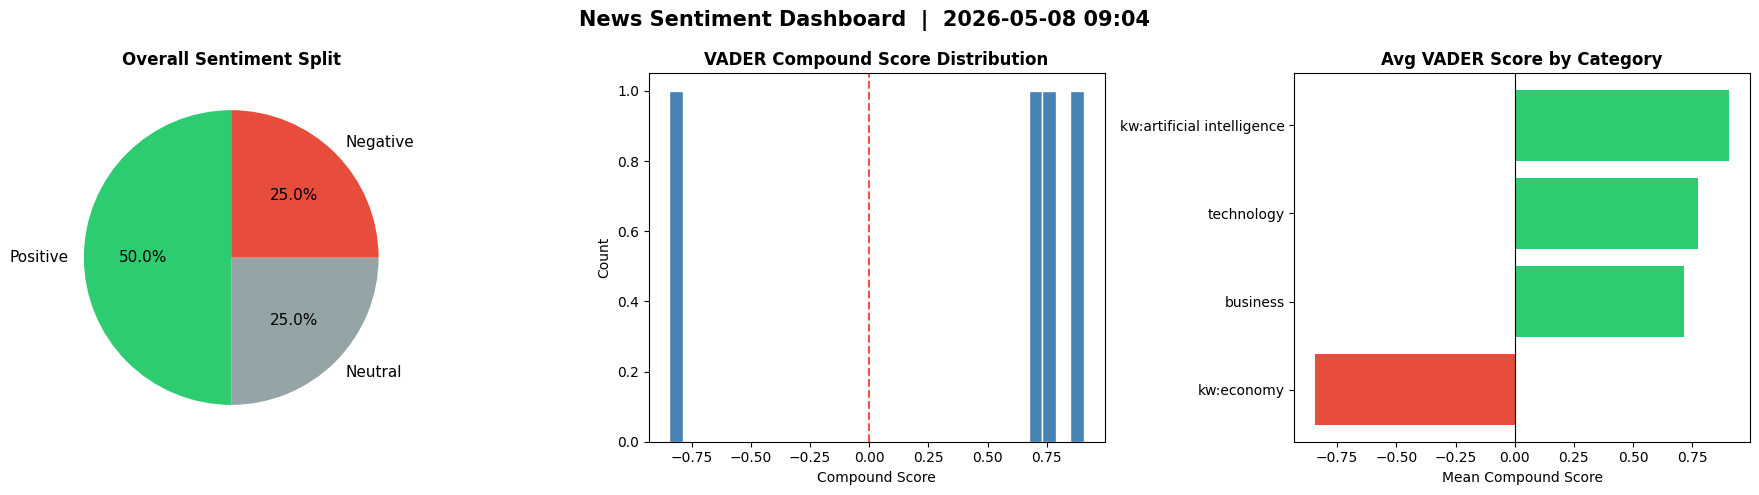

✅ Dashboard Panel 1 displayed


In [52]:
# ── Dashboard Panel 1: Sentiment Overview Pie ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"News Sentiment Dashboard  |  {datetime.now().strftime('%Y-%m-%d %H:%M')}",
            fontsize=15, fontweight='bold')
# Panel 1 — Overall pie
counts = df["consensus_label"].value_counts()
axes[0].pie(
   counts.values,
   labels=counts.index,
   colors=[COLOR_MAP[l] for l in counts.index],
   autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11}
)
axes[0].set_title("Overall Sentiment Split", fontweight='bold')
# Panel 2 — VADER compound distribution histogram
axes[1].hist(df["vader_compound"], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', alpha=0.7)
axes[1].set_title("VADER Compound Score Distribution", fontweight='bold')
axes[1].set_xlabel("Compound Score")
axes[1].set_ylabel("Count")
# Panel 3 — Average sentiment per category
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values()
colors  = ['#e74c3c' if v < 0 else '#2ecc71' for v in cat_avg.values]
axes[2].barh(cat_avg.index, cat_avg.values, color=colors)
axes[2].axvline(0, color='black', linewidth=0.8)
axes[2].set_title("Avg VADER Score by Category", fontweight='bold')
axes[2].set_xlabel("Mean Compound Score")
plt.tight_layout()
plt.show()
print("✅ Dashboard Panel 1 displayed")

In [53]:
# ── Print final summary ──────────────────────────────────────────
print("="*60)
print(" NEWS SENTIMENT DASHBOARD — SUMMARY REPORT")
print(f" Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*60)
print(f" Total articles analysed : {len(df)}")
print(f" Categories covered      : {', '.join(df['category'].unique())}")
print(f" Unique sources          : {df['source'].nunique()}")
print()
print(" SENTIMENT BREAKDOWN:")
for label, count in df['consensus_label'].value_counts().items():
   pct = count / len(df) * 100
   bar = '█' * int(pct / 3)
   print(f"   {label:10s} {bar:30s} {count:4d} ({pct:.1f}%)")
print()
print(" MOST POSITIVE CATEGORIES:")
cat_avg = df.groupby('category')['vader_compound'].mean().sort_values(ascending=False)
for cat, score in cat_avg.items():
   emoji = '🟢' if score > 0.05 else ('🔴' if score < -0.05 else '⚪')
   print(f"   {emoji} {cat:20s} score: {score:+.3f}")
print()
print(" TOP KEYWORDS IN HEADLINES:")
for word, count in freq_dist.most_common(10):
   print(f"   {word:20s} {count} mentions")
print("="*60)

 NEWS SENTIMENT DASHBOARD — SUMMARY REPORT
 Generated: 2026-05-08 09:05:04
 Total articles analysed : 4
 Categories covered      : technology, business, kw:economy, kw:artificial intelligence
 Unique sources          : 4

 SENTIMENT BREAKDOWN:
   Positive   ████████████████                  2 (50.0%)
   Neutral    ████████                          1 (25.0%)
   Negative   ████████                          1 (25.0%)

 MOST POSITIVE CATEGORIES:
   🟢 kw:artificial intelligence score: +0.906
   🟢 technology           score: +0.776
   🟢 business             score: +0.717
   🔴 kw:economy           score: -0.844

 TOP KEYWORDS IN HEADLINES:
   stranger             3 mentions
   heaven               3 mentions
   shivon               3 mentions
   notes                3 mentions
   might                3 mentions
   important            3 mentions
   evidence             3 mentions
   seen                 3 mentions
   far                  3 mentions
   self                 3 mentions


In [ ]:
# ── Export final DataFrame to CSV ────────────────────────────────
output_cols = [
   'title', 'source', 'category', 'published_at',
   'vader_compound', 'vader_label',
   'tb_polarity', 'tb_subjectivity', 'tb_label',
   'consensus_label', 'token_count', 'url'
]
df[output_cols].to_csv('news_sentiment_results.csv', index=False)
print("✅ Results saved to news_sentiment_results.csv")
print(f"   Shape: {df[output_cols].shape}")
df[output_cols].head()

✅ Results saved to news_sentiment_results.csv
   Shape: (4, 12)


,title,source,category,published_at,vader_compound,vader_label,tb_polarity,tb_subjectivity,tb_label,consensus_label,token_count,url
0,STRANGER THAN HEAVEN launches this winter - Ge...,Gematsu,technology,2026-05-06T23:36:02Z,0.7761,Positive,-0.600000,1.000000,Negative,Neutral,43,https://www.gematsu.com/2026/05/stranger-than-...
1,Musk’s biggest loyalist became his biggest lia...,The Verge,business,2026-05-06T23:37:02Z,0.7166,Positive,0.272727,0.681818,Positive,Positive,42,https://www.theverge.com/ai-artificial-intelli...
2,Experts warn increasing self-reliance comes at...,ABC News (AU),kw:economy,2026-05-07T02:37:24Z,-0.8442,Negative,0.046667,0.240000,Neutral,Negative,47,https://www.abc.net.au/news/2026-05-07/nationa...
3,"India, Japan sign quantum technology and healt...",BusinessLine,kw:artificial intelligence,2026-05-07T02:33:37Z,0.9062,Positive,0.000000,1.000000,Neutral,Positive,38,https://www.thehindubusinessline.com/news/scie...
